In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = pd.read_csv("bank.csv", sep=',')
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
None
                age       balance           day      duration      campaign  \
count  11162.00

In [4]:
for col in data.columns:
  if data[col].dtype == 'object':
    mode = data[col].mode()[0]
    data[col]= data[col].replace('unknown',mode)

In [5]:
le = LabelEncoder()

for col in data.columns:
  if data[col].dtype == 'object':
    data[col]= le.fit_transform(data[col])

In [6]:
X = data.drop('deposit', axis=1)
y = data['deposit']

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [7]:
dt_model = DecisionTreeClassifier(
    criterion = 'entropy',
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [8]:
# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Accuracy: 0.7819

Confusion Matrix:
 [[876 290]
 [197 870]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.75      0.78      1166
           1       0.75      0.82      0.78      1067

    accuracy                           0.78      2233
   macro avg       0.78      0.78      0.78      2233
weighted avg       0.78      0.78      0.78      2233



In [9]:
# Re-apply LabelEncoder to the correctly parsed data
le = LabelEncoder()

for col in data.columns:
  if data[col].dtype == 'object':
    data[col]= le.fit_transform(data[col])

print("Label encoding re-applied.")

Label encoding re-applied.


In [10]:
# Re-split features and target, and then perform train-test split
X = data.drop('deposit', axis=1)
y = data['deposit']

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

print("Data split into training and testing sets.")

Data split into training and testing sets.


In [11]:
# Re-fit the Decision Tree model
dt_model = DecisionTreeClassifier(
    criterion = 'entropy',
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree model re-fitted successfully.")

Decision Tree model re-fitted successfully.


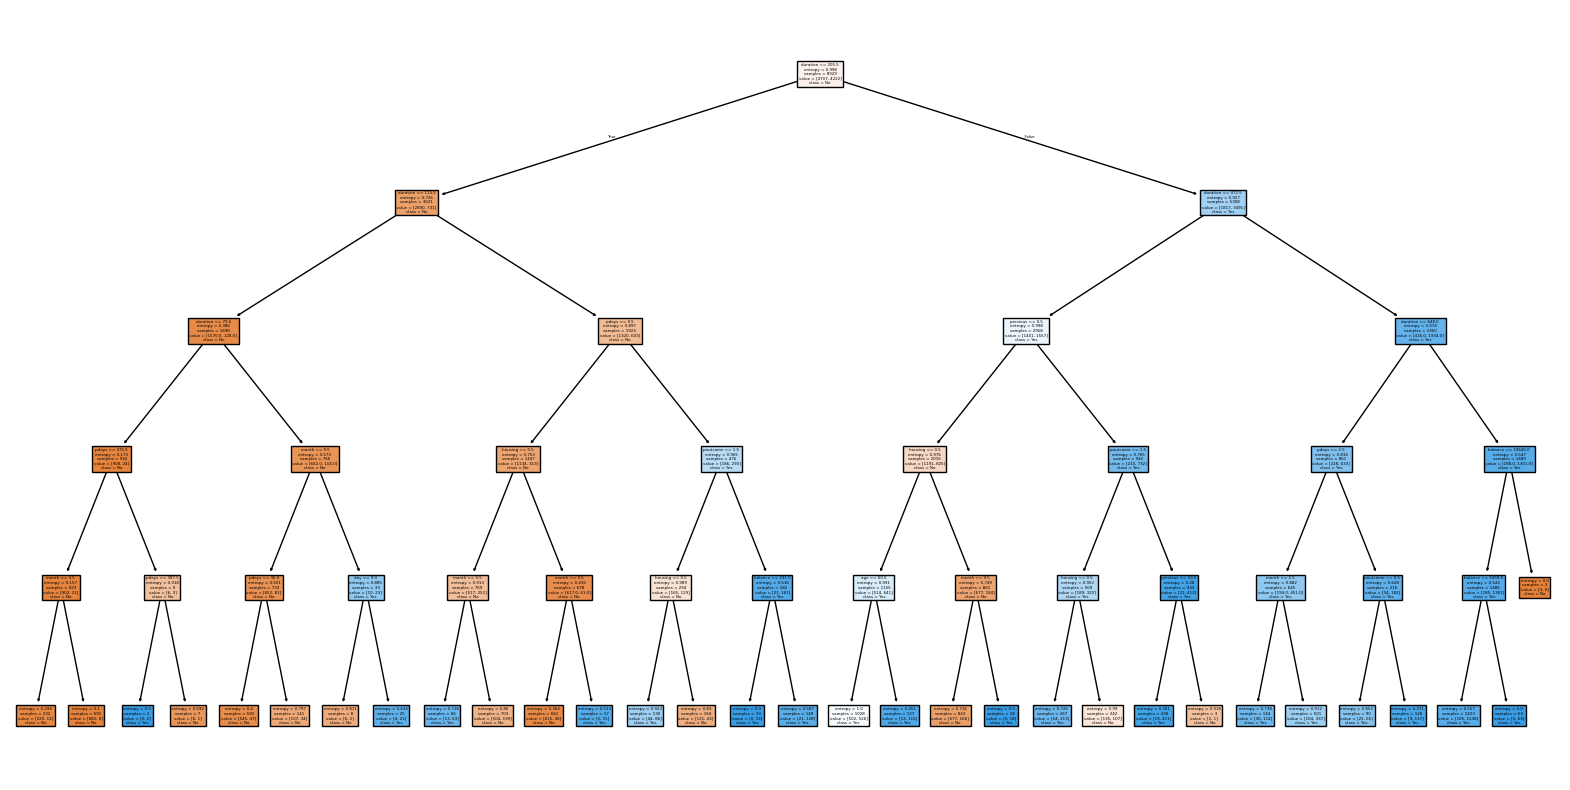

In [12]:
plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True
)
plt.show()

In [13]:
y_pred = dt_model.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7819077474249888

Confusion Matrix: 
 [[876 290]
 [197 870]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.75      0.78      1166
           1       0.75      0.82      0.78      1067

    accuracy                           0.78      2233
   macro avg       0.78      0.78      0.78      2233
weighted avg       0.78      0.78      0.78      2233

